# Discover context length for local LlamaFactory data

Notebook này đo trực tiếp bốn split trong `data/llamafactory` bằng chat template native của từng tokenizer.

- `prompt_length`: token của `system + user` **kèm assistant generation header**.
- `max_length`: token của toàn bộ `system + user + assistant` **kèm EOS/template tokens**.
- Không truncation trong lúc đo; vì vậy kết quả dùng được để chọn `cutoff_len`.
- Qwen chạy với `enable_thinking=False`, khớp `qwen3_nothink` trong YAML.
- Llama 3 có thể cần `HF_TOKEN` nếu tokenizer/model repository đang gated.


In [1]:
from __future__ import annotations

import json
import math
import os
import statistics
from pathlib import Path
from typing import Any, Iterator

from tqdm.auto import tqdm
from transformers import AutoTokenizer

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').is_file() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

DATA_DIR = ROOT / 'data' / 'llamafactory'
SPLITS = {
    'train': DATA_DIR / 'cypher_prepared_train.jsonl',
    'validation': DATA_DIR / 'cypher_prepared_eval.jsonl',
    'test_generator': DATA_DIR / 'cypher_prepared_test_generator.jsonl',
    'test_selector': DATA_DIR / 'cypher_prepared_test_selector.jsonl',
}
MODEL_SPECS = {
    'qwen3': {
        'model_name': 'Qwen/Qwen3-0.6B',
        'template_kwargs': {'enable_thinking': False},
        'current_cutoff_len': 892,
    },
    'llama3': {
        'model_name': 'meta-llama/Llama-3.2-1B-Instruct',
        'template_kwargs': {},
        'current_cutoff_len': 899,
    },
}

# Đặt số nguyên để smoke-test nhanh; None phân tích toàn bộ dữ liệu.
MAX_ROWS: int | None = None
HF_TOKEN = os.getenv('HF_TOKEN') or os.getenv('HF_READ_TOKEN')
LOCAL_FILES_ONLY = True  # Both configured tokenizers are cached locally.

print('Repository:', ROOT)
print('Data directory:', DATA_DIR)


d:\GitHub\cypher-extract\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository: D:\GitHub\cypher-extract
Data directory: D:\GitHub\cypher-extract\data\llamafactory


In [2]:
def iter_jsonl(path: Path, max_rows: int | None = None) -> Iterator[tuple[int, dict[str, Any]]]:
    with path.open('r', encoding='utf-8') as handle:
        emitted = 0
        for line_number, line in enumerate(handle, 1):
            if not line.strip():
                continue
            if max_rows is not None and emitted >= max_rows:
                return
            record = json.loads(line)
            if not isinstance(record, dict):
                raise ValueError(f'{path}:{line_number} is not a JSON object')
            emitted += 1
            yield line_number, record


def count_jsonl(path: Path) -> int:
    with path.open('r', encoding='utf-8') as handle:
        return sum(bool(line.strip()) for line in handle)


def percentile(sorted_values: list[int], quantile: float) -> float:
    if not sorted_values:
        raise ValueError('Cannot summarize an empty length list')
    if len(sorted_values) == 1:
        return float(sorted_values[0])
    position = (len(sorted_values) - 1) * quantile
    lower = math.floor(position)
    upper = math.ceil(position)
    if lower == upper:
        return float(sorted_values[lower])
    weight = position - lower
    return sorted_values[lower] * (1.0 - weight) + sorted_values[upper] * weight


def summarize(values: list[int]) -> dict[str, float | int]:
    ordered = sorted(values)
    return {
        'count': len(ordered),
        'min': ordered[0],
        'mean': sum(ordered) / len(ordered),
        'median': statistics.median(ordered),
        'p90': percentile(ordered, 0.90),
        'p95': percentile(ordered, 0.95),
        'p99': percentile(ordered, 0.99),
        'max': ordered[-1],
    }


def validate_messages(record: dict[str, Any], path: Path, line_number: int) -> list[dict[str, str]]:
    messages = record.get('messages')
    if not isinstance(messages, list) or len(messages) < 2:
        raise ValueError(f'{path}:{line_number} has no valid messages list')
    if messages[-1].get('role') != 'assistant':
        raise ValueError(f'{path}:{line_number} must end with an assistant message')
    for message in messages:
        if not isinstance(message.get('role'), str) or not isinstance(message.get('content'), str):
            raise ValueError(f'{path}:{line_number} contains a malformed message')
    return messages


def chat_token_ids(
    tokenizer,
    messages: list[dict[str, str]],
    *,
    add_generation_prompt: bool,
    template_kwargs: dict[str, Any],
) -> list[int]:
    token_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=add_generation_prompt,
        **template_kwargs,
    )
    # transformers may return a list or a BatchEncoding depending on version.
    if hasattr(token_ids, 'keys') and 'input_ids' in token_ids:
        token_ids = token_ids['input_ids']
    if not isinstance(token_ids, list):
        token_ids = token_ids.tolist()
    return token_ids


def example_preview(messages: list[dict[str, str]], line_number: int) -> dict[str, Any]:
    user_content = next((m['content'] for m in messages if m['role'] == 'user'), '')
    return {
        'line_number': line_number,
        'user_preview': user_content[:240].replace('\n', ' '),
        'assistant_preview': messages[-1]['content'][:160].replace('\n', ' '),
    }


def analyze_split(
    path: Path,
    tokenizer,
    *,
    template_kwargs: dict[str, Any],
    cutoff_len: int,
    max_rows: int | None = None,
) -> tuple[dict[str, Any], dict[str, Any]]:
    prompt_lengths: list[int] = []
    full_lengths: list[int] = []
    target_lengths: list[int] = []
    longest_prompt: dict[str, Any] | None = None
    longest_full: dict[str, Any] | None = None

    total = min(count_jsonl(path), max_rows) if max_rows is not None else count_jsonl(path)
    iterator = tqdm(iter_jsonl(path, max_rows), total=total, desc=path.stem)
    for line_number, record in iterator:
        messages = validate_messages(record, path, line_number)
        prompt_ids = chat_token_ids(
            tokenizer,
            messages[:-1],
            add_generation_prompt=True,
            template_kwargs=template_kwargs,
        )
        full_ids = chat_token_ids(
            tokenizer,
            messages,
            add_generation_prompt=False,
            template_kwargs=template_kwargs,
        )
        prompt_length = len(prompt_ids)
        full_length = len(full_ids)
        target_length = max(full_length - prompt_length, 0)
        prompt_lengths.append(prompt_length)
        full_lengths.append(full_length)
        target_lengths.append(target_length)

        if longest_prompt is None or prompt_length > longest_prompt['prompt_length']:
            longest_prompt = example_preview(messages, line_number) | {'prompt_length': prompt_length}
        if longest_full is None or full_length > longest_full['max_length']:
            longest_full = example_preview(messages, line_number) | {
                'prompt_length': prompt_length,
                'max_length': full_length,
                'target_length': target_length,
            }

    if not full_lengths:
        raise ValueError(f'No records found in {path}')
    over_cutoff = sum(length > cutoff_len for length in full_lengths)
    summary = {
        'rows': len(full_lengths),
        'prompt_length': summarize(prompt_lengths),
        'max_length': summarize(full_lengths),
        'target_length': summarize(target_lengths),
        'current_cutoff_len': cutoff_len,
        'rows_over_current_cutoff': over_cutoff,
        'percent_over_current_cutoff': 100.0 * over_cutoff / len(full_lengths),
    }
    longest = {'prompt': longest_prompt, 'full': longest_full}
    return summary, longest


In [3]:
missing_files = [str(path) for path in SPLITS.values() if not path.is_file()]
if missing_files:
    raise FileNotFoundError(f'Missing LlamaFactory splits: {missing_files}')

split_rows = {name: count_jsonl(path) for name, path in SPLITS.items()}
split_rows


{'train': 10027,
 'validation': 3414,
 'test_generator': 2348,
 'test_selector': 35281}

In [4]:
analysis: dict[str, dict[str, Any]] = {}
longest_examples: dict[str, dict[str, Any]] = {}
load_errors: dict[str, str] = {}

for model_key, spec in MODEL_SPECS.items():
    print(f'\nLoading tokenizer: {spec["model_name"]}')
    try:
        tokenizer = AutoTokenizer.from_pretrained(
            spec['model_name'],
            token=HF_TOKEN,
            use_fast=True,
            local_files_only=LOCAL_FILES_ONLY,
        )
    except Exception as error:
        load_errors[model_key] = f'{type(error).__name__}: {error}'
        print(f'SKIP {model_key}: {load_errors[model_key]}')
        continue

    # Prevent warning-only truncation messages; apply_chat_template still receives no truncation option.
    tokenizer.model_max_length = 10**9
    analysis[model_key] = {}
    longest_examples[model_key] = {}
    for split_name, split_path in SPLITS.items():
        summary, longest = analyze_split(
            split_path,
            tokenizer,
            template_kwargs=spec['template_kwargs'],
            cutoff_len=spec['current_cutoff_len'],
            max_rows=MAX_ROWS,
        )
        analysis[model_key][split_name] = summary
        longest_examples[model_key][split_name] = longest

if load_errors:
    print('\nTokenizer load errors:')
    print(json.dumps(load_errors, ensure_ascii=False, indent=2))



Loading tokenizer: Qwen/Qwen3-0.6B


cypher_prepared_test_selector: 100%|██████████| 35281/35281 [01:02<00:00, 567.79it/s]



Loading tokenizer: meta-llama/Llama-3.2-1B-Instruct


cypher_prepared_test_selector: 100%|██████████| 35281/35281 [01:07<00:00, 520.28it/s]


In [5]:
columns = [
    'model', 'split', 'rows', 'max_prompt_length', 'p95_prompt',
    'max_length', 'p95_length', 'over_cutoff', 'over_cutoff_pct',
]
table_rows: list[dict[str, Any]] = []
for model_key, split_summaries in analysis.items():
    for split_name, summary in split_summaries.items():
        table_rows.append({
            'model': model_key,
            'split': split_name,
            'rows': summary['rows'],
            'max_prompt_length': summary['prompt_length']['max'],
            'p95_prompt': round(summary['prompt_length']['p95'], 1),
            'max_length': summary['max_length']['max'],
            'p95_length': round(summary['max_length']['p95'], 1),
            'over_cutoff': summary['rows_over_current_cutoff'],
            'over_cutoff_pct': round(summary['percent_over_current_cutoff'], 2),
        })

widths = {column: max(len(column), *(len(str(row[column])) for row in table_rows)) for column in columns}
print(' | '.join(column.ljust(widths[column]) for column in columns))
print('-+-'.join('-' * widths[column] for column in columns))
for row in table_rows:
    print(' | '.join(str(row[column]).ljust(widths[column]) for column in columns))


model  | split          | rows  | max_prompt_length | p95_prompt | max_length | p95_length | over_cutoff | over_cutoff_pct
-------+----------------+-------+-------------------+------------+------------+------------+-------------+----------------
qwen3  | train          | 10027 | 524               | 437.0      | 608        | 509.0      | 0           | 0.0            
qwen3  | validation     | 3414  | 519               | 424.0      | 612        | 497.0      | 0           | 0.0            
qwen3  | test_generator | 2348  | 502               | 462.0      | 600        | 535.0      | 0           | 0.0            
qwen3  | test_selector  | 35281 | 255               | 213.0      | 258        | 217.0      | 0           | 0.0            
llama3 | train          | 10027 | 541               | 455.0      | 625        | 526.0      | 0           | 0.0            
llama3 | validation     | 3414  | 536               | 442.0      | 629        | 513.3      | 0           | 0.0            
llama3 | test_ge

In [6]:
def round_up(value: int, multiple: int = 8) -> int:
    return math.ceil(value / multiple) * multiple

yaml_values: dict[str, dict[str, int]] = {}
for model_key, split_summaries in analysis.items():
    max_prompt_length = max(item['prompt_length']['max'] for item in split_summaries.values())
    max_length = max(item['max_length']['max'] for item in split_summaries.values())
    train_validation_max = max(
        split_summaries[name]['max_length']['max'] for name in ('train', 'validation')
    )
    yaml_values[model_key] = {
        'max_prompt_length': max_prompt_length,
        'max_length': max_length,
        'train_validation_max_length': train_validation_max,
        'cutoff_len_rounded_to_8_all_splits': round_up(max_length),
        'cutoff_len_rounded_to_8_train_validation': round_up(train_validation_max),
        'rollout_context_length_rounded_to_8': round_up(max_prompt_length),
    }

print(json.dumps(yaml_values, ensure_ascii=False, indent=2))
print('\nNote: rollout_context_length must be smaller than cutoff_len to leave room for the assistant response.')


{
  "qwen3": {
    "max_prompt_length": 524,
    "max_length": 612,
    "train_validation_max_length": 612,
    "cutoff_len_rounded_to_8_all_splits": 616,
    "cutoff_len_rounded_to_8_train_validation": 616,
    "rollout_context_length_rounded_to_8": 528
  },
  "llama3": {
    "max_prompt_length": 541,
    "max_length": 629,
    "train_validation_max_length": 629,
    "cutoff_len_rounded_to_8_all_splits": 632,
    "cutoff_len_rounded_to_8_train_validation": 632,
    "rollout_context_length_rounded_to_8": 544
  }
}

Note: rollout_context_length must be smaller than cutoff_len to leave room for the assistant response.


In [7]:
report = {
    'dataset_files': {name: str(path.relative_to(ROOT)) for name, path in SPLITS.items()},
    'model_specs': MODEL_SPECS,
    'max_rows': MAX_ROWS,
    'analysis': analysis,
    'yaml_values': yaml_values,
    'longest_examples': longest_examples,
    'tokenizer_load_errors': load_errors,
}
report_path = DATA_DIR / 'context_length_analysis.json'
report_path.write_text(
    json.dumps(report, ensure_ascii=False, indent=2, sort_keys=True) + '\n',
    encoding='utf-8',
)
print('Saved:', report_path)
longest_examples


Saved: D:\GitHub\cypher-extract\data\llamafactory\context_length_analysis.json


{'qwen3': {'train': {'prompt': {'line_number': 3613,
    'user_preview': 'QUESTION: List the names of players who have been part of clubs that have used Stadion An der Alten Försterei as their home venue, and for each player, provide the number of such clubs they have played for.  SCHEMA: {   "nodes": [     {    ',
    'assistant_preview': '{"cypher": "MATCH (n:Player)-[r0:playsFor]->(m0:Club)-[r1:hasHomeVenue]->(m1:Venue {name: \'Stadion An der Alten Försterei\'}) WITH n, count(DISTINCT m0) AS num R',
    'prompt_length': 524},
   'full': {'line_number': 5979,
    'user_preview': 'QUESTION: How many clubs have either used Stadio Olimpico Grande Torino as their home venue or had Marcello Mihalich as a player at some point?  SCHEMA: {   "nodes": [     {       "label": "Club",       "properties": {         "country": "S',
    'assistant_preview': '{"cypher": "CALL { MATCH (n:Club)-[r0:hasHomeVenue]->(m0:Venue {name: \'Stadio Olimpico Grande Torino\'}) RETURN n, m0 as m UNION MATCH (n:Clu

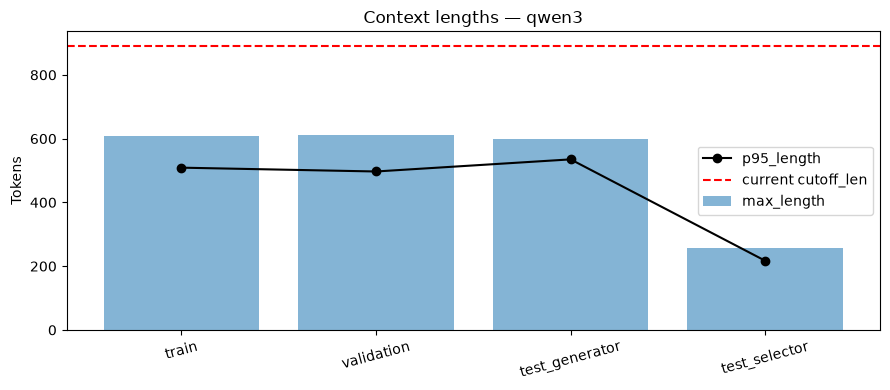

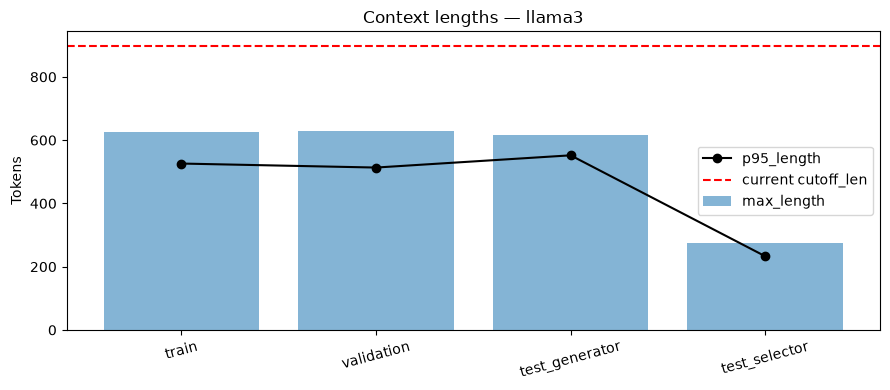

In [8]:
# Optional: compare max and p95 lengths across splits without storing every tokenized row.
import matplotlib.pyplot as plt

for model_key, split_summaries in analysis.items():
    names = list(split_summaries)
    maxima = [split_summaries[name]['max_length']['max'] for name in names]
    p95 = [split_summaries[name]['max_length']['p95'] for name in names]
    x = range(len(names))
    plt.figure(figsize=(9, 4))
    plt.bar(x, maxima, alpha=0.55, label='max_length')
    plt.plot(x, p95, marker='o', color='black', label='p95_length')
    plt.axhline(MODEL_SPECS[model_key]['current_cutoff_len'], color='red', linestyle='--', label='current cutoff_len')
    plt.xticks(list(x), names, rotation=15)
    plt.ylabel('Tokens')
    plt.title(f'Context lengths — {model_key}')
    plt.legend()
    plt.tight_layout()
    plt.show()
